In [7]:
from pathlib import Path
from eoflow.ea import EAWaterQualityAPI, get_ea_water_quality
from eoflow.utils import load_shapefile
import folium
import pandas as pd
from eoflow.rivers import get_river_network_from_shape 

In [4]:
try:
    file_path = Path(__file__).resolve()
except NameError:
    file_path = Path.cwd()

shapefile_path = file_path.parent.parent.parent / "data/Counties_and_Unitary_Authorities_December_2023_Boundaries"
assert shapefile_path.is_dir()

In [5]:
gdf = load_shapefile(path=shapefile_path)
devon_gdf = gdf[gdf["CTYUA23NM"] == "Devon"]
devon_gdf

,CTYUA23CD,CTYUA23NM,CTYUA23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
134,E10000008,Devon,None,283143,93085,-3.65698,50.7256,7aa8a35e-fa29-49bf-ac91-e4b121754500,"MULTIPOLYGON (((264838.577 43779.215, 264643.3..."


In [6]:

devon_gdf = devon_gdf.to_crs(epsg=4326)

# # Compute a sensible center for the map
geom_name = devon_gdf.geometry.name
centroid = devon_gdf.geometry.unary_union.centroid
map_center = [centroid.y, centroid.x]

# tooltip_fields = [c for c in gdf.columns if c != geom_name][:5]
# tooltip = folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_fields) if tooltip_fields else None

m = folium.Map(
    location=map_center, 
    zoom_start=9,
    width="400px",
    height="400px",
    scrollWheelZoom=False)

folium.GeoJson(
    devon_gdf.__geo_interface__,
    name="shapefile",
    style_function=lambda feat: {
        "fillColor": "#ff7800",
        "color": "black",
        "weight": 0.5,
        "fillOpacity": 0.4,
    },
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m

/tmp/ipykernel_361575/770127517.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = devon_gdf.geometry.unary_union.centroid


In [14]:
devon_gdf

,CTYUA23CD,CTYUA23NM,CTYUA23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
134,E10000008,Devon,None,283143,93085,-3.65698,50.7256,7aa8a35e-fa29-49bf-ac91-e4b121754500,"MULTIPOLYGON (((-3.8983 50.27846, -3.90103 50...."


/tmp/ipykernel_361575/1266985395.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = devon_gdf["geometry"].unary_union


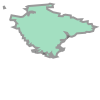

In [35]:
from shapely import Polygon
poly = devon_gdf["geometry"].unary_union
poly = poly.simplify(
    tolerance=.01,  # degrees — tune this
)
poly


In [36]:
osm_rivers = get_river_network_from_shape(poly)

2026-02-02 11:52:39,762 - eoflow.rivers - DEBUG - Built Overpass query with poly containing 3647 characters
2026-02-02 11:52:39,763 - eoflow.rivers - INFO - Querying Overpass for waterways in boundary (poly string: 3647 chars)
2026-02-02 11:52:39,763 - eoflow.rivers - DEBUG - Posting Overpass query attempt=1/6 endpoint=https://overpass-api.de/api/interpreter


OverpassError: Overpass HTTP error from https://overpass-api.de/api/interpreter: 400 Client Error: Bad Request for url: https://overpass-api.de/api/interpreter

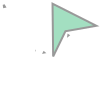

In [32]:
poly